# Model building for golf putting

This case study reproduces the model-building sequence in Andrew Gelman's
[golf putting case study](https://mc-stan.org/learn-stan/case-studies/golf.html) using Bambi.
The goal is not merely to fit a curve. We begin with a conventional regression, identify where
its shape conflicts with the physical problem, replace it with a model derived from geometry,
and then test and expand that model with new data.

In [1]:
# | code-fold: true
%config InlineBackend.figure_format = "retina"
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("bambi.mplstyle")


## The original putting data

The observations are aggregate counts of successful putts at distances from 2 through 20 feet.

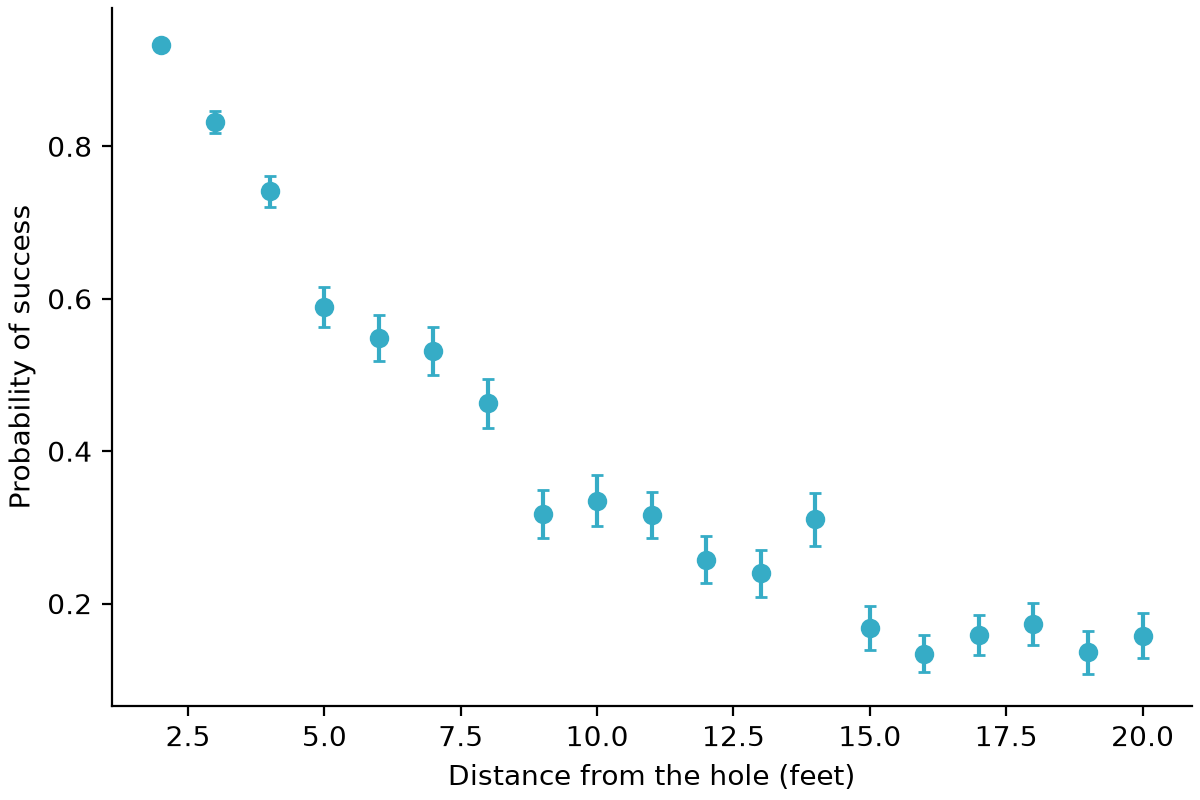

In [2]:
golf = pd.read_csv("data/golf.csv")
golf["success_rate"] = golf["successes"] / golf["attempts"]

standard_error = np.sqrt(
    golf["success_rate"] * (1 - golf["success_rate"]) / golf["attempts"]
)
plt.errorbar(
    golf["distance"],
    golf["success_rate"],
    yerr=standard_error,
    fmt="o",
    capsize=2,
)
plt.xlabel("Distance from the hole (feet)")
plt.ylabel("Probability of success")
plt.show()


### A conventional logistic regression

A natural statistical starting point is a Binomial regression with a linear predictor on the
log-odds scale:

$$
y_j \sim \operatorname{Binomial}(n_j, p_j), \qquad
\operatorname{logit}(p_j) = a + b x_j.
$$

This is an ordinary Bambi generalized linear model. `prop()` retains the number of attempts behind
each observed success proportion.

NUTS[nutpie]: [distance, Intercept_centered]


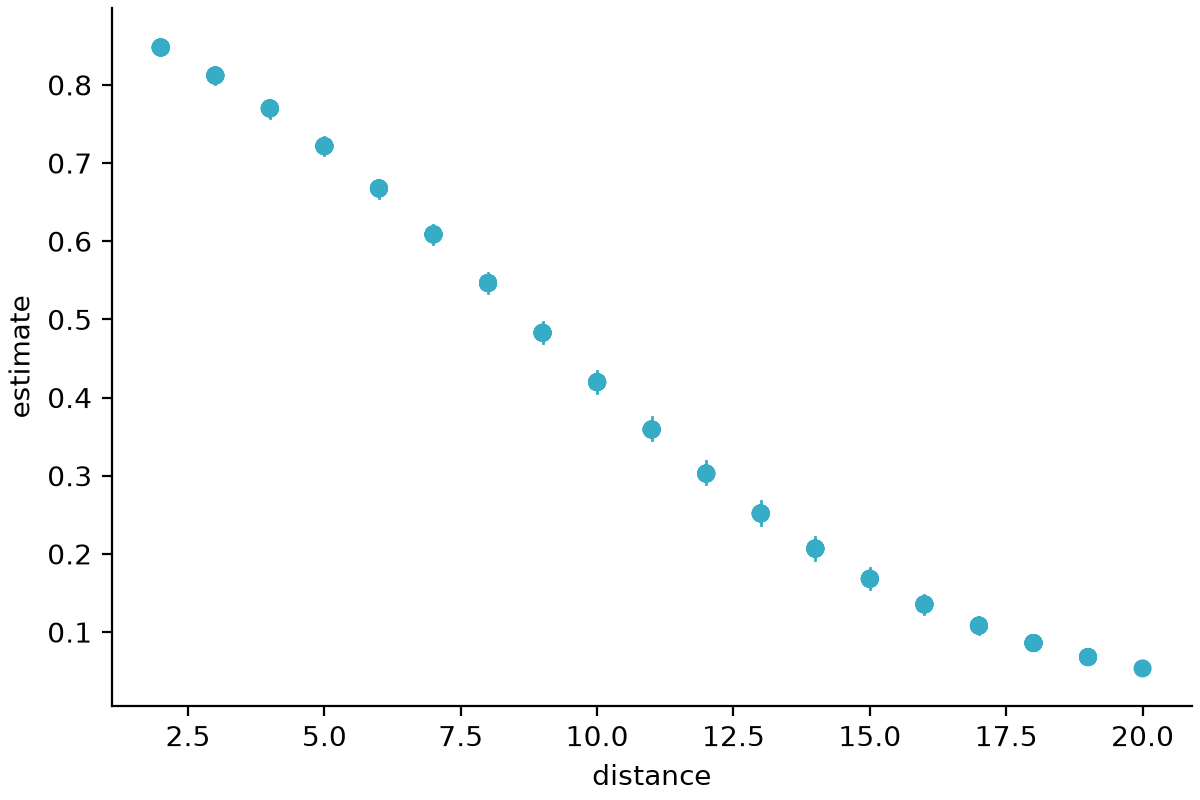

In [3]:
logistic_model = bmb.Model(
    "prop(successes, attempts) ~ distance",
    golf,
    family="binomial",
)
logistic_idata = logistic_model.fit(random_seed=123, progressbar=False)

bmb.interpret.plot_predictions(
    logistic_model,
    logistic_idata,
    conditional={"distance": np.linspace(2, 20, 100)},
)


The logistic curve is convenient but not based on how a putt succeeds. In particular, extrapolating
it toward zero distance does not force the success probability toward one.

## A model from first principles

A golf ball of radius $r$ can enter a hole of radius $R$ when its angular error is smaller than

$$
\theta(x) = \sin^{-1}\left(\frac{R-r}{x}\right).
$$

Assume the golfer aims straight and the realized angle is normally distributed around zero with
standard deviation $\sigma_{\mathrm{angle}}$. The probability that its magnitude is within the
threshold is

$$
p_{\mathrm{angle}}(x) =
2\Phi\left(\frac{\theta(x)}{\sigma_{\mathrm{angle}}}\right)-1.
$$

The radii are converted from inches to feet to match `distance`.

In [4]:
golf["ball_radius"] = (1.68 / 2) / 12
golf["hole_radius"] = (4.25 / 2) / 12

angle_formula = bmb.Formula(
    "prop(successes, attempts) ~ "
    "2 * normal_cdf("
    "asin((hole_radius - ball_radius) / distance) / sigma_angle"
    ") - 1",
    nlpars=("sigma_angle",),
)

angle_model = bmb.Model(
    angle_formula,
    golf,
    family="binomial",
    link="identity",
    priors={
        "sigma_angle": {
            "Intercept": bmb.Prior("HalfNormal", sigma=0.5),
        }
    },
)
angle_idata = angle_model.fit(random_seed=123, progressbar=False)

NUTS[nutpie]: [sigma_angle_Intercept]



The nonlinear expression already returns a probability, so the Binomial parent uses the identity
link. The positive prior reflects that `sigma_angle` is a standard deviation. Its posterior is in
radians; converting it to degrees gives the directly interpretable angular error.

In [5]:
sigma_angle_degrees = np.rad2deg(angle_idata.posterior["sigma_angle_Intercept"])
az.summary(sigma_angle_degrees.rename("sigma_angle_degrees"))

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_angle_degrees,1.528,0.0225,1.5,1.6,1679,2280,1.00,0.00055,0.00034



The posterior mean is approximately 1.53 degrees, matching the original analysis. We can compare
the statistical and physical curves through the same `interpret` API.

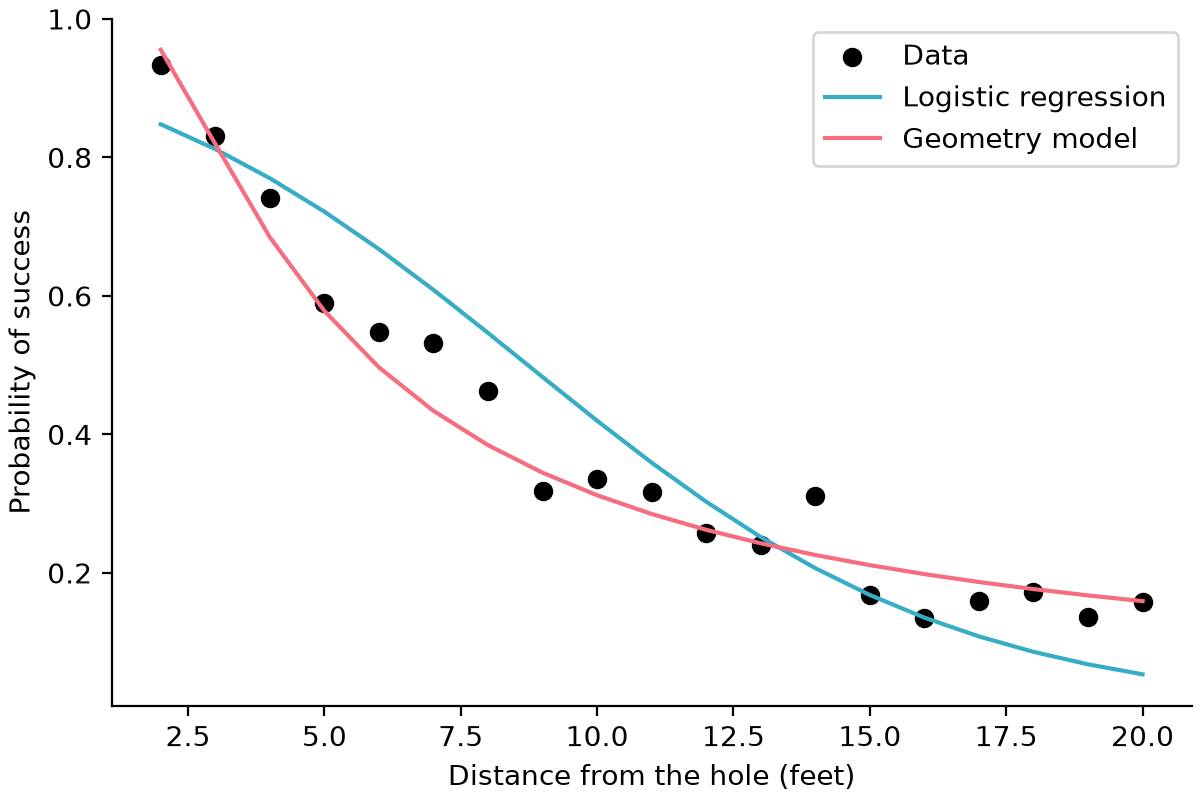

In [6]:
distance_grid = np.linspace(2, 20, 100)

logistic_predictions = bmb.interpret.predictions(
    logistic_model,
    logistic_idata,
    conditional={"distance": distance_grid},
).summary
angle_predictions = bmb.interpret.predictions(
    angle_model,
    angle_idata,
    conditional={"distance": distance_grid},
).summary

plt.scatter(golf["distance"], golf["success_rate"], color="black", label="Data")
plt.plot(
    logistic_predictions["distance"],
    logistic_predictions["estimate"],
    label="Logistic regression",
)
plt.plot(
    angle_predictions["distance"],
    angle_predictions["estimate"],
    label="Geometry model",
)
plt.xlabel("Distance from the hole (feet)")
plt.ylabel("Probability of success")
plt.legend()
plt.show()


The first-principles curve captures the short-distance behavior and fits the observed shape better
with only one unknown scientific parameter.

## Testing the model on new data

Mark Broadie's larger dataset contains many more attempts and extends beyond 75 feet. We deliberately
carry the already-fitted angular model forward rather than refitting it; this is a posterior
predictive test of what the original model learned.

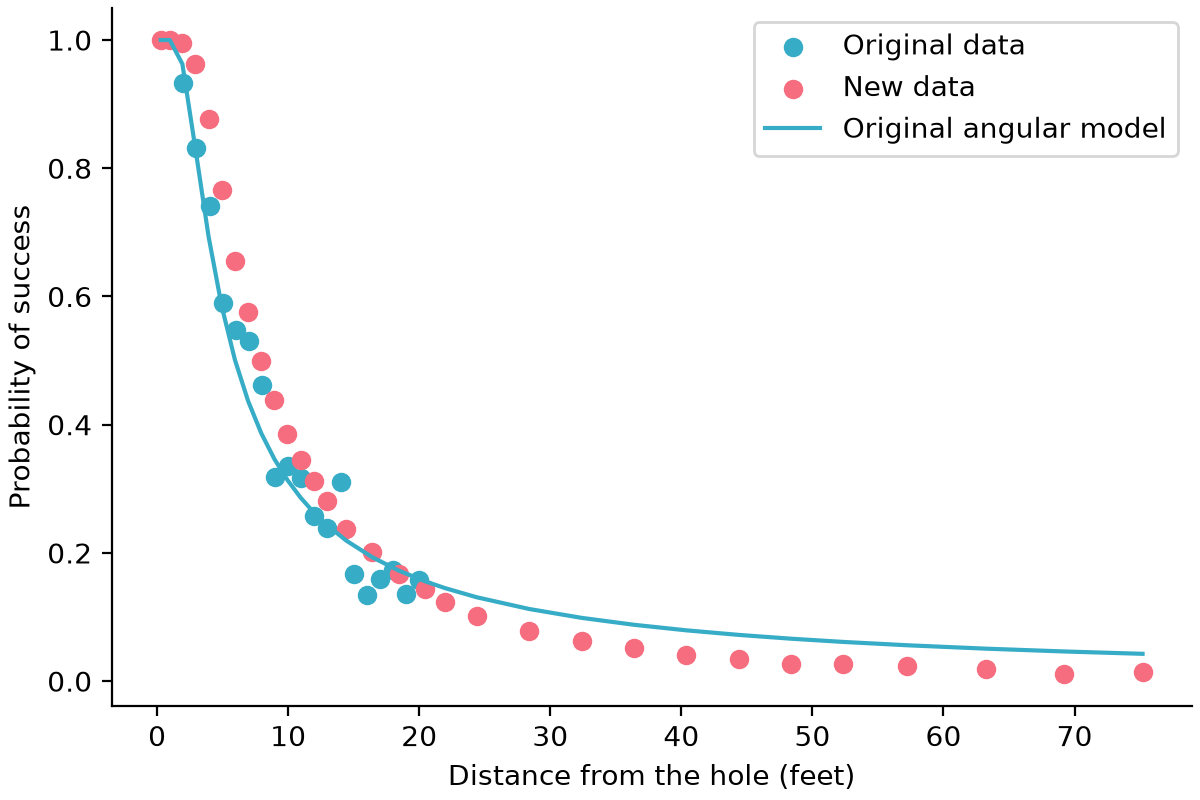

In [7]:
golf_extended = pd.read_csv("data/golf_extended.csv")
golf_extended["success_rate"] = golf_extended["successes"] / golf_extended["attempts"]
golf_extended["ball_radius"] = (1.68 / 2) / 12
golf_extended["hole_radius"] = (4.25 / 2) / 12

angle_on_new = angle_model.predict(
    angle_idata,
    data=golf_extended,
    inplace=False,
)
predicted_probability = angle_on_new.predictions["p"].mean(("chain", "draw"))

plt.scatter(
    golf["distance"],
    golf["success_rate"],
    label="Original data",
)
plt.scatter(
    golf_extended["distance"],
    golf_extended["success_rate"],
    label="New data",
)
plt.plot(
    golf_extended["distance"],
    predicted_probability,
    label="Original angular model",
)
plt.xlabel("Distance from the hole (feet)")
plt.ylabel("Probability of success")
plt.legend()
plt.show()


The model overpredicts long putts. Angular accuracy is not enough: a putt must also be struck hard
enough to reach the hole, but not so hard that it rolls across without falling.

## Adding distance control

Following Broadie, suppose a golfer aims one foot past the hole and has multiplicative distance
error with standard deviation $\sigma_{\mathrm{distance}}$. A putt is struck acceptably when its
potential distance lies between $x$ and $x+3$ feet. Its distance-success probability is

$$
p_{\mathrm{distance}}(x) =
\Phi\left(\frac{2}{(x+1)\sigma_{\mathrm{distance}}}\right)
-
\Phi\left(\frac{-1}{(x+1)\sigma_{\mathrm{distance}}}\right).
$$

Assuming angular and distance errors are independent, the complete success probability is
$p_{\mathrm{angle}}p_{\mathrm{distance}}$. The fixed assumptions are stored as data columns so the
formula names their scientific roles.

In [8]:
golf_extended["overshot"] = 1.0
golf_extended["distance_tolerance"] = 3.0

angle_distance_formula = bmb.Formula(
    "prop(successes, attempts) ~ "
    "(2 * normal_cdf("
    "asin((hole_radius - ball_radius) / distance) / sigma_angle"
    ") - 1) * "
    "(normal_cdf("
    "(distance_tolerance - overshot) / "
    "((distance + overshot) * sigma_distance)"
    ") - normal_cdf("
    "-overshot / ((distance + overshot) * sigma_distance)"
    "))",
    nlpars=("sigma_angle", "sigma_distance"),
)

angle_distance_model = bmb.Model(
    angle_distance_formula,
    golf_extended,
    family="binomial",
    link="identity",
    priors={
        "sigma_angle": {
            "Intercept": bmb.Prior("HalfNormal", sigma=1),
        },
        "sigma_distance": {
            "Intercept": bmb.Prior("HalfNormal", sigma=1),
        },
    },
)
angle_distance_idata = angle_distance_model.fit(
    random_seed=123,
    cores=1,
    progressbar=False,
)

az.summary(
    angle_distance_idata,
    var_names=["sigma_angle_Intercept", "sigma_distance_Intercept"],
)

NUTS[nutpie]: [sigma_angle_Intercept, sigma_distance_Intercept]


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_angle_Intercept,0.013288,5.6e-05,0.013,0.013,523,622,1.00,2.5e-06,1.4e-06
sigma_distance_Intercept,0.13727,0.00051,0.14,0.14,510,647,1.00,2.3e-05,1.3e-05


/var/folders/yp/g4z_ylx565j4hzgny6j2phtc0000gn/T/ipykernel_61636/597695471.py:26: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


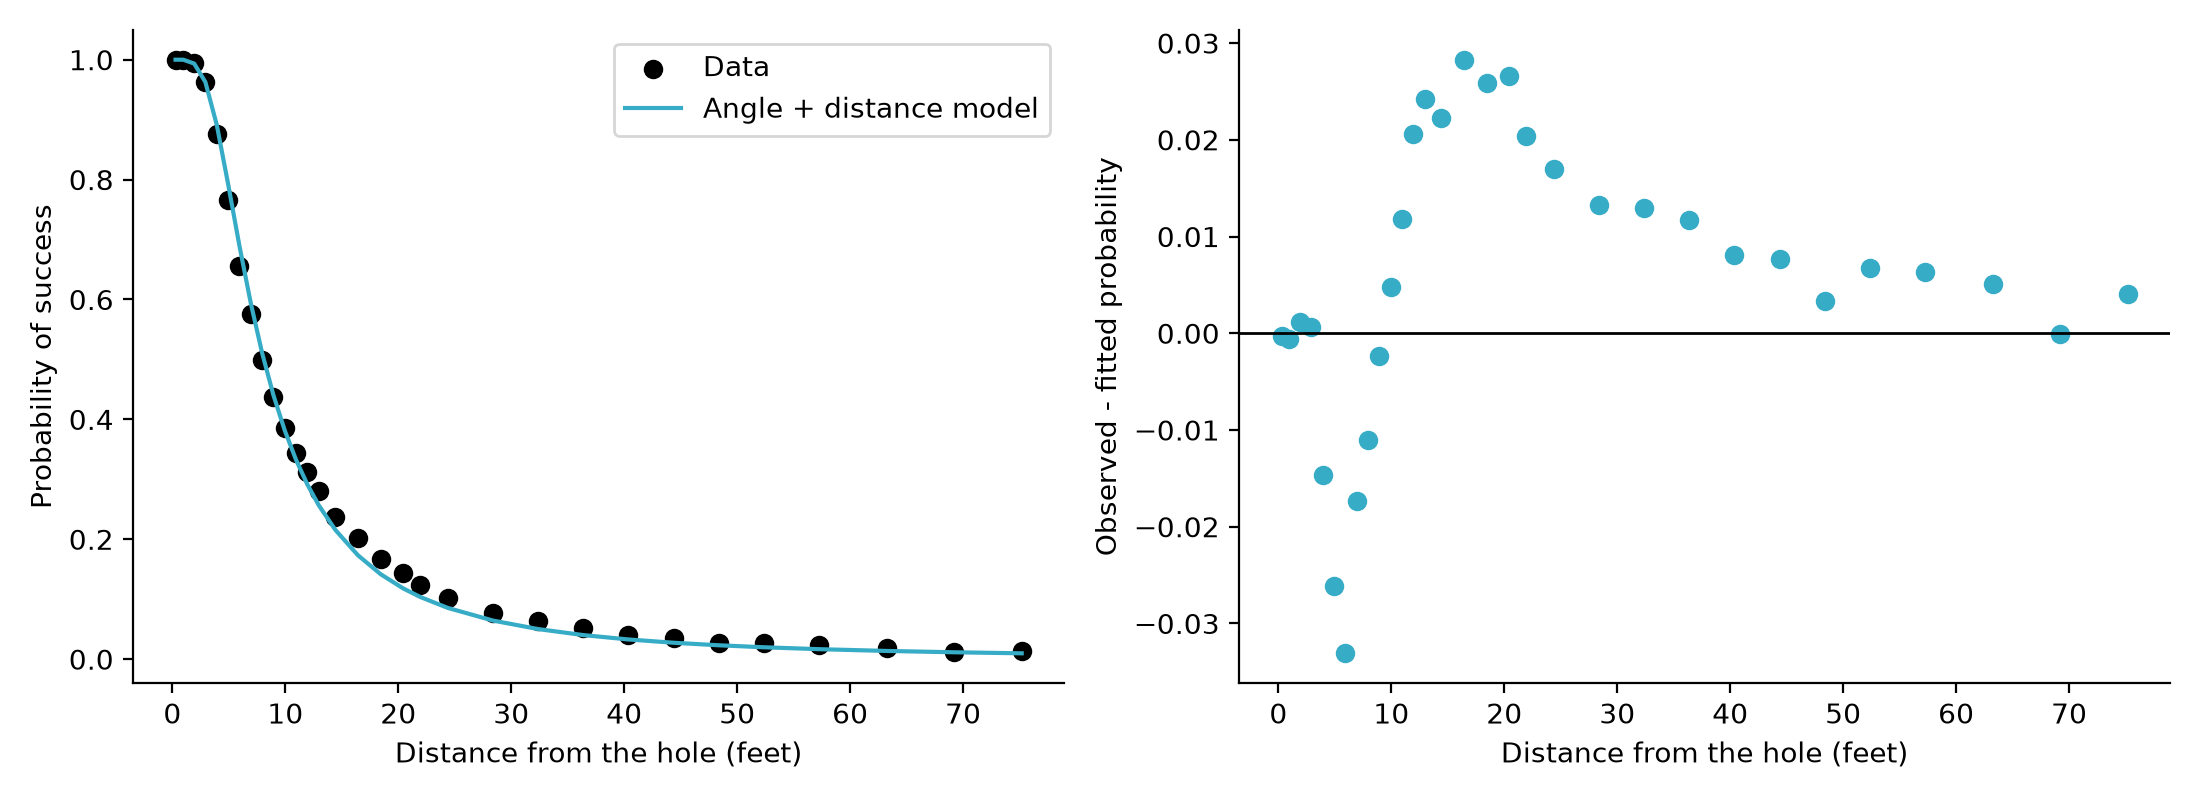

In [9]:
angle_distance_fitted = angle_distance_model.predict(
    angle_distance_idata,
    data=golf_extended,
    inplace=False,
)
fitted_probability = angle_distance_fitted.predictions["p"].mean(("chain", "draw"))
residual = golf_extended["success_rate"] - fitted_probability

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(
    golf_extended["distance"], golf_extended["success_rate"], color="black", label="Data"
)
axes[0].plot(golf_extended["distance"], fitted_probability, label="Angle + distance model")
axes[0].set(
    xlabel="Distance from the hole (feet)",
    ylabel="Probability of success",
)
axes[0].legend()

axes[1].axhline(0, color="black", linewidth=1)
axes[1].scatter(golf_extended["distance"], residual)
axes[1].set(
    xlabel="Distance from the hole (feet)",
    ylabel="Observed - fitted probability",
)
fig.tight_layout()
plt.show()


This is a model we can write in Bambi, but it exposes the same problem as the original case study:
the enormous attempt counts make the Binomial likelihood demand nearly exact agreement at the
most heavily sampled distances. Sampling diagnostics and the systematic lack of fit should not be
ignored simply because the model can be expressed.

## Modeling the remaining variation

Gelman and Broadie address the misspecification by approximating each observed proportion with a
Normal distribution and adding an irreducible residual scale $\sigma_y$:

$$
\frac{y_j}{n_j} \sim \operatorname{Normal}\left(
p_j,
\sqrt{\frac{p_j(1-p_j)}{n_j}+\sigma_y^2}
\right).
$$

The nonlinear parameter graph can express this directly. The mean `mu` composes the angle and
distance probabilities, while Gaussian `sigma` depends on both `mu` and the separately estimated
`sigma_y`. Bambi resolves those dependencies before constructing the PyMC graph.

In [10]:
golf_residual_formula = bmb.Formula(
    "success_rate ~ p_angle * p_distance",
    "p_angle ~ "
    "2 * normal_cdf("
    "asin((hole_radius - ball_radius) / distance) / sigma_angle"
    ") - 1",
    "p_distance ~ "
    "normal_cdf("
    "(distance_tolerance - overshot) / "
    "((distance + overshot) * sigma_distance)"
    ") - normal_cdf("
    "-overshot / ((distance + overshot) * sigma_distance)"
    ")",
    "sigma ~ sqrt(mu * (1 - mu) / attempts + sigma_y ** 2)",
    nlpars=(
        "p_angle",
        "p_distance",
        "sigma_angle",
        "sigma_distance",
        "sigma_y",
    ),
)

golf_residual_model = bmb.Model(
    golf_residual_formula,
    golf_extended,
    family="gaussian",
    link="identity",
    priors={
        "sigma_angle": {
            "Intercept": bmb.Prior("HalfNormal", sigma=1),
        },
        "sigma_distance": {
            "Intercept": bmb.Prior("HalfNormal", sigma=1),
        },
        "sigma_y": {
            "Intercept": bmb.Prior("HalfNormal", sigma=0.1),
        },
    },
)
golf_residual_idata = golf_residual_model.fit(
    random_seed=123,
    cores=1,
    progressbar=False,
)

az.summary(
    golf_residual_idata,
    var_names=[
        "sigma_angle_Intercept",
        "sigma_distance_Intercept",
        "sigma_y_Intercept",
    ],
)

NUTS[nutpie]: [sigma_angle_Intercept, sigma_distance_Intercept, sigma_y_Intercept]


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_angle_Intercept,0.017803,0.000103,0.018,0.018,589,736,1.00,4.3e-06,3.2e-06
sigma_distance_Intercept,0.0801,0.00128,0.078,0.082,651,763,1.01,5.1e-05,3.8e-05
sigma_y_Intercept,0.00306,0.0006,0.0022,0.0041,846,997,1.00,2e-05,1.4e-05



The final model in the original case study also tries estimating `overshot` and
`distance_tolerance` instead of fixing them. Those quantities could appear as nonlinear parameters
in the mean expression. The original analysis finds them weakly identified, so this example keeps
them fixed and focuses on the residual-scale dependency.

## What the sequence demonstrates

The progression uses Bambi's ordinary generalized linear models, aggregated Binomial responses,
nonlinear expressions, parameter dependencies, constrained priors, posterior transformations,
out-of-sample prediction, and `interpret` with the same model interface. More importantly, it
illustrates a statistical
workflow: begin simply, use scientific structure to improve the mean, test on new data, take
diagnostics seriously, and model the remaining variation explicitly.